<a href="https://colab.research.google.com/github/OlaHPH/assignments/blob/main/Assignment%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSIGNMENT 3 #

### Statement of use of AI ###
AI is used for explaining concepts, debugging, and suggesting alternative solutions. Assignment solution is conducted based on my own understanding. The code is compiled, ran, and tested by myself.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Task 0: Setting up Ollama (1p) ##

In [ ]:
#install openAI package
!pip install openai
#Load the 270m parameter version of the gemma3 model (gemma3:270m)
!ollama pull gemma3:270m
#Load the 1b parameter version of the gemma3 model (gemma3:1b)
!ollama pull gemma3:1b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest 
pulling 735af2139dc6: 100% ▕██████████████████▏ 291 MB                         
pulling 4b19ac7dd2fb: 100% ▕██████████████████▏  476 B                         
pulling 3e2c24001f9e: 100% ▕██████████████████▏ 8.4 KB                         
pulling 339e884a40f6: 100% ▕██████████████████▏   61 B                         
pulling 74156d92caf6: 100% ▕██████████████████▏  490 B                         
verifying sha256 digest 
writing manifest 
success 
pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest 
pulling 7cd4618c1faf: 100% ▕██████████████████▏ 815 MB                         
pulling e0a42594d802: 100% ▕██████████████████▏  358 B                         
pulling dd084c7d92a3: 100% ▕██████████████████▏ 8.4 KB                         
pulling 3116c5225075: 100

In [ ]:
from openai import OpenAI

ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)
# define a helper function that sends a prompt and returns the response text.
def ask_llm(prompt,model):
    """Send a prompt to the local LLM and return the response text."""
    response = ollama_client.chat.completions.create(
        model = model,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

#b Load the 270m parameter version of the gemma3 model (gemma3:270m) and test it with any prompt
print('Testing with gemma3:270m')
print(ask_llm("Explain Python dictionary, tuple, list in 2 sentences. ","gemma3:270m"))
#c Load the 1b parameter version of the gemma3 (gemma3:1b) and test it with any prompt.
print('Testing with gemma3:1b')
print(ask_llm("Explain Python dictionary, tuple, list in 2 sentences. ","gemma3:1b"))


Testing with gemma3:270m
Python dictionaries, tuples, and lists are fundamental data structures used to store and manipulate data in a structured and organized way. They provide a way to define, store, and retrieve data based on predefined rules, making them versatile for various applications.

Testing with gemma3:1b
A **dictionary** is a collection of key-value pairs where each key is unique and maps to a value. A **tuple** is an ordered, immutable collection of items, similar to a list but with stricter requirements for elements. 

A **list** is an ordered, mutable sequence of items, offering flexibility in order and allowing for additions or removals.


## Task 1: Text classification with Ollama (2p) ##

Using `data/emails.csv` dataset for this task. The file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone.


In [ ]:
#load the csv file
with open("C:/Users/User/Documents/emails.csv", 'r', encoding='utf-8') as f:
    headlines = f.read().splitlines()

df = pd.DataFrame(headlines[1:], columns=['headline'])  # skip first row (header)
print(df.shape)
df.head()

(12, 1)


,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


In [ ]:
#a) Make a function for classifying emails (based on the headlines) as spam, work or unknown.The function should return only the classification and nothing else. (0.5p)
def email_classification (headline,model):
     prompt = f"""You are an email classifier.
Your task is to classify email headlines.
You must reply with exactly one of these three words: spam, work, unknown.
Do not write anything else.
Headline: {headline}
Classification: """
     classification = ask_llm(prompt, model).strip().lower()
     return classification

In [ ]:
#b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)
print([email_classification(t,"gemma3:270m") for t in df['headline']])

['spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam']


In [ ]:
#c) Use larger gemma3 (4b) to classify the emails using the function created in part a)
# In separate markdown cell, write a brief comment comparing the results of parts b) and c).
print([email_classification(t,"gemma3:4b") for t in df['headline']])

['spam', 'spam', 'spam', 'spam', 'work', 'work', 'work', 'work', 'work', 'work', 'work', 'unknown']


### Comparing the results ###

Using the same prompts on the same sample, the smaller model gemma3 (270m) though faster, provided much 'poorer' classification of the emails based on the headers.
On many previous tests, it returned more than one 'classification' word or completely strange text out of the assigned ones (unknown, work, spam).
The larger gemma3:4b, though takes longer to run, seems to perform much better in the classification as it correcly identifies the 3 categories and returns them in one word as prompted.

In [ ]:
#d) Write a script that repeats b) and c) 3 times, storing the results for both models separately.
#For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models.
#Comment if there were differences and explain why this happened. (0.5p)
df_results = df.copy()
for i in range (3):
    df_results[f'270m_run{i+1}'] = [email_classification(t,'gemma3:270m') for t in df['headline']]
    df_results[f'4b_run{i+1}'] = [email_classification(t,'gemma3:4b') for t in df['headline']]

display(df_results)

,headline,270m_run1,4b_run1,270m_run2,4b_run2,270m_run3,4b_run3
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,unknown,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,work,spam,work,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work,spam,work,spam,work
6,Reminder: Annual performance review scheduled ...,spam,work,spam,work,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work,spam,work,spam,work
8,Quick question about last week,spam,work,spam,work,spam,work
9,Following up,spam,work,spam,work,spam,work


By putting the results together, again we can see that using the same prompt, on the same sample, the smaller model (gemma3:270m) would classify all the emal as 'spam' or event output strange texts which is not included in the range of words prompted, i.e. 'spam', 'work', 'unknown' while the larger model (gemma3:4b) more consistenly and precisely label the emails based on the headers. The reason could lie within the size of the models.  

## Task 2: Sentiment analysis with Ollama (2p) ##
The data/news.csv file contains 10 fictional financial news headlines is for all subtasks in this task.

In [ ]:
#load the csv file
with open("C:/Users/User/Documents/news.csv", 'r', encoding='utf-8') as f:
    news_headline = f.read().splitlines()
# load the file into a dataframe, skip first row (header)
df_news = pd.DataFrame(news_headline[1:], columns=['news_headline'])
display(df_news)

,news_headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


In [ ]:
#a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics)
# and for determining the sentiment of the news (positive, negative, neutral).
#The function should return the class and sentiment in JSON format. (1p)
def news_analysis (headline,model):
    prompt = f"""You are an email analyzer.
First, classify the news based on the topics with only one of these words : earnings, mergers, regulation, or macroeconomics.
Second, determinine the sentiment of the news with only one of these words: positive, negative, or neutral.
Then, return only the result of your classification and sentiment analysis, do not write anything else.
Headline: {headline}
Return only this json:
{{"classification: "...","sentiment":"...."}}
"""
    result = ask_llm(prompt, model).strip()
    return result

In [ ]:
#testing 270m model
print('Testing with 270m model')
print(df_news['news_headline'][2])
print(news_analysis(df_news['news_headline'][2],"gemma3:270m"))

Testing with 270m model
Aurelis Bank reports steady quarterly profit, in line with analyst expectations
```json
{"classification: "...","sentiment":"...."}
```


In [ ]:
#testing 4b model
print('Testing with 4b model')
print(df_news['news_headline'][2])
print(news_analysis(df_news['news_headline'][2],"gemma3:4b"))

Testing with 4b model
Aurelis Bank reports steady quarterly profit, in line with analyst expectations
{"classification":"earnings","sentiment":"positive"}


In [ ]:
#b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment.
import json

analysis = []

for i in df_news['news_headline']:
    raw = news_analysis(i,"gemma3:4b")
    parsed = json.loads(raw)
    result = {'news_headline':i,**parsed}
    analysis.append(result)

df_news_analysis_4b = pd.DataFrame(analysis)
display(df_news_analysis_4b)

,news_headline,classification,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,positive
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


In [ ]:
#c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options.
#Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

### Compare the results when using a browser-based LLM (Gemini) ###

I used Gemini (Gemini 3 Flash) to verify the results using the same prompt and same dataset.
The prompt is identical as in the function above with much faster responstime. The reason behind could be:
in comparison to gemma3:270m and gemma3:4b, Gemini Flash 3 has much larger parameter counts,
with bigger context window (1.0 x 10^6, vs 3.2 x 10^4 tokens of gemma3:270m and 1.28 x 10^5 tokens of gemma3:4b).
That would explain the speed and accuracy on benchmarks.

  "You are an email analyzer.
First, classify the news based on the topics with only one of these words : earnings, mergers, regulation, or macroeconomics.
Second, determinine the sentiment of the news with only one of these words: positive, negative, or neutral.
Then, return only the result of your classification and sentiment analysis, do not write anything else.
Headline: {headline}
Return only this json:
{{"classification: "...","sentiment":"...."}}"

The output:
[
  {"classification": "earnings", "sentiment": "positive"},
  {"classification": "earnings", "sentiment": "negative"},
  {"classification": "earnings", "sentiment": "neutral"},
  {"classification": "mergers", "sentiment": "positive"},
  {"classification": "regulation", "sentiment": "negative"},
  {"classification": "mergers", "sentiment": "neutral"},
  {"classification": "regulation", "sentiment": "negative"},
  {"classification": "regulation", "sentiment": "positive"},
  {"classification": "macroeconomics", "sentiment": "positive"},
  {"classification": "macroeconomics", "sentiment": "negative"}
]

## Task 3: Supervised machine learning (5p) ##
For this task, subset of the Bank Marketing dataset, i.e., bank-additional.csv from the UCI repository is used.
The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

d) Compare using train, validation and test set split versus using cross-validation - not finished

e) Report and evaluate the performance of the models (1p) - missing

In [ ]:
#a) Import the dataset and conduct exploratory data analysis on it. (1p)
df_bank = pd.read_csv("C:/Users/User/Documents/bank-additional.csv", sep =';')
display(df_bank.head())
df_bank.shape
df_bank.info()
df_bank.describe()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df_bank['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [ ]:
#verify the count of 'unknown' values through the dataset
for col in df_bank.columns:
    unknown_count = (df_bank[col] == 'unknown').sum()
    if unknown_count > 0:
        percentage = (unknown_count/len(df_bank)*100).round(2)
        print(f"{col}: {unknown_count} unknown values {percentage}%")

job: 39 unknown values 0.95%
marital: 11 unknown values 0.27%
education: 167 unknown values 4.05%
default: 803 unknown values 19.5%
housing: 105 unknown values 2.55%
loan: 105 unknown values 2.55%


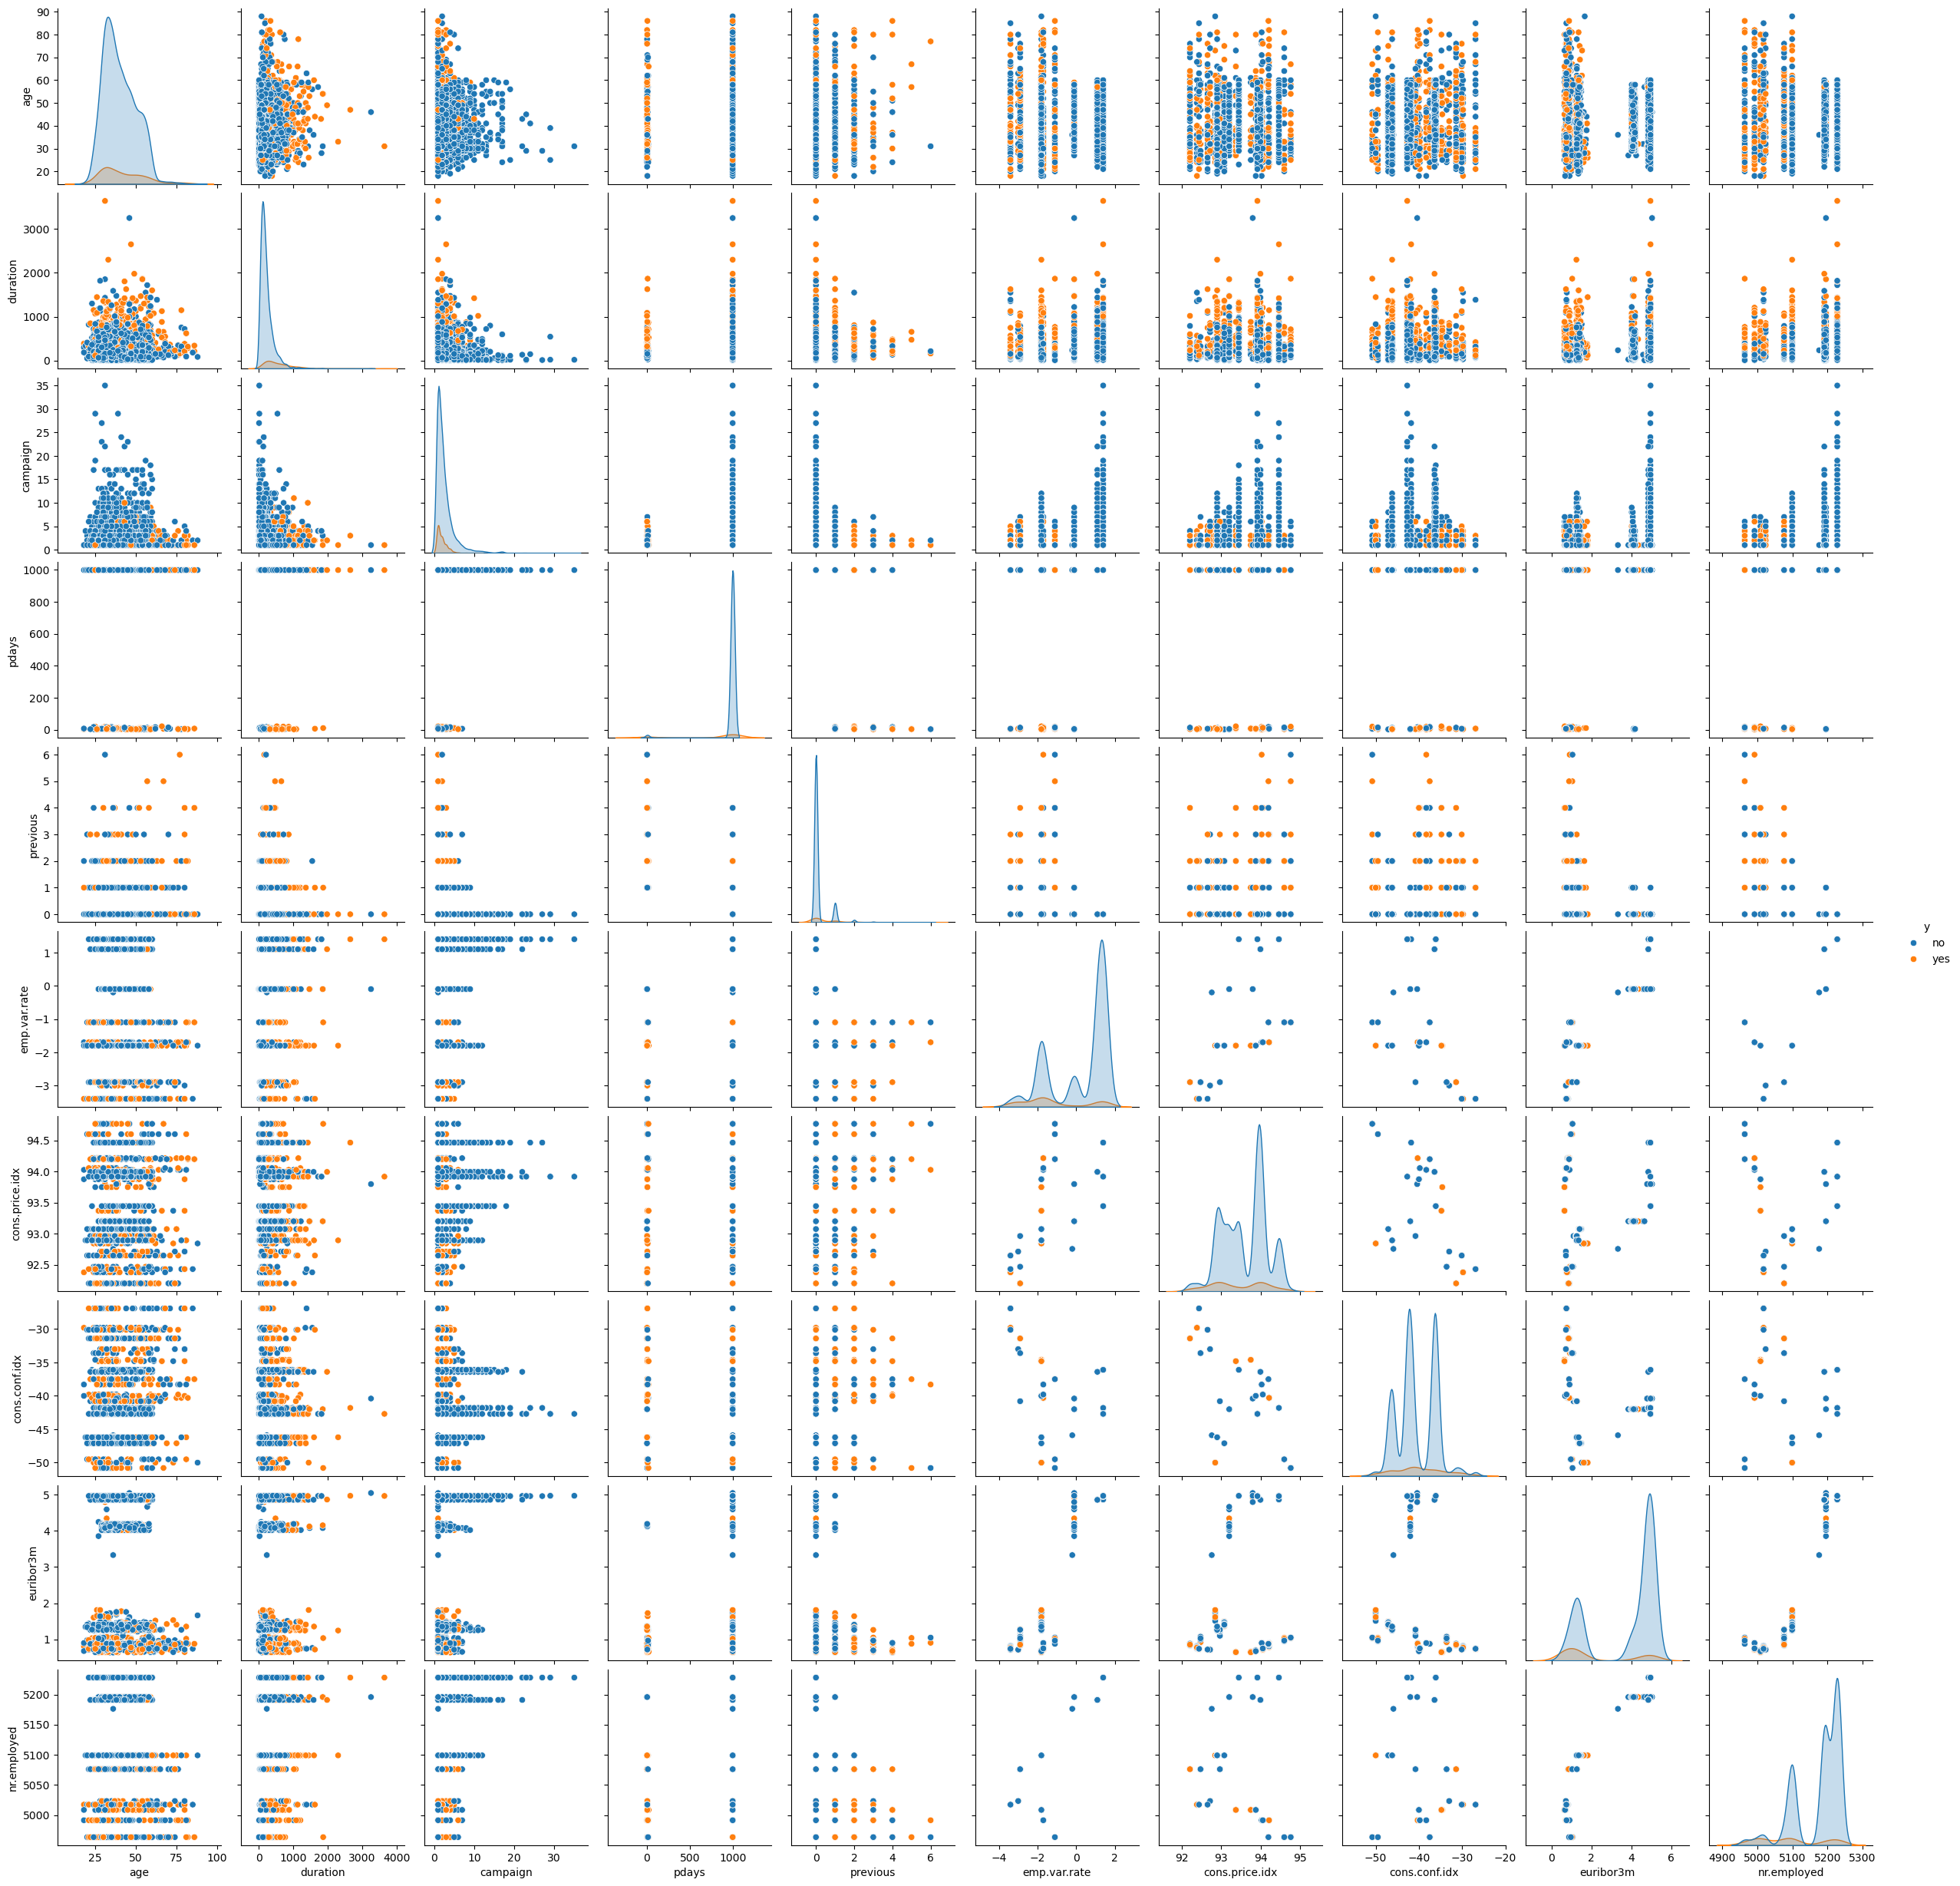

In [ ]:
#explore correlations between all pairs of numerical values
sns.pairplot(df_bank,hue='y')
plt.show()

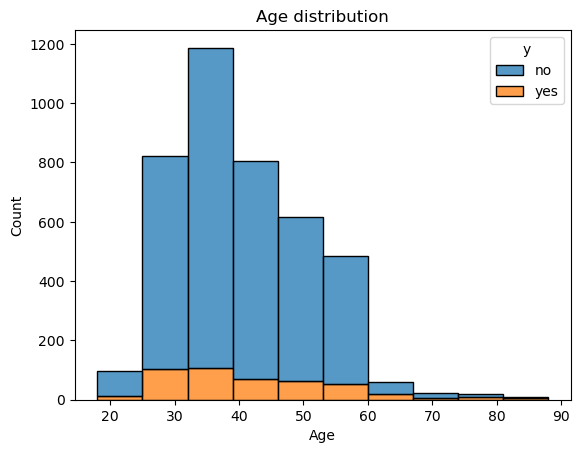

In [ ]:
sns.histplot(data=df_bank,x='age',hue = 'y', bins=10, multiple = 'stack')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

b) Preprocessing the data using dropping, one-hot encoding, label encoding and standardization

In [ ]:
#preprocessing
#dropping duration due to dataset description "Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model."
#dropping pdays as 75% of values is 999 i.e. client was not contacted previously
df_bank = df_bank.drop(columns=['duration','pdays'])
display(df_bank.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [ ]:
#preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#one-hot encoding for variable with no natural order - job, marital, defautlt, housing, loan, contact, month, day_of_week,poutcome
df_bank = pd.get_dummies(df_bank, columns=['job','marital','contact','month','day_of_week','poutcome'], drop_first=True, dtype=float)

#label encoding for ordinal variable - education
le_education = LabelEncoder()
df_bank['education'] = le_education.fit_transform(df_bank['education'])

#encode 'y' numerically (1 = yes, 0 = no)
df_bank['y'] = df_bank['y'].map({'yes':1,'no':0})

#encode 'default', 'housing,'loan' numerically (1 = yes, 0 = no, 2 = unknown)
#dataset note: 8. Missing Attribute Values: There are several missing values in some categorical attributes, all coded with the "unknown" label.
#These missing values can be treated as a possible class label or using deletion or imputation techniques.
for col in ['default','housing','loan']:
   df_bank[col] = df_bank[col].map({'yes':1,'no':0,'unknown':2})

#standardization for numerical values including campaign, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
scaler_standard = StandardScaler()
df_bank[['age','campaign', 'previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']] = scaler_standard.fit_transform(df_bank[['age','campaign', 'previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']])

display(df_bank)

,age,education,default,housing,loan,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,-0.980752,2,0,1,0,-0.209228,-0.351356,-1.206054,-1.185448,-1.240939,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.107991,3,0,0,0,0.569634,-0.351356,0.649441,0.715193,0.892269,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.465619,3,0,1,0,-0.598660,-0.351356,0.841389,1.528273,-0.283172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-0.204965,2,0,2,2,0.180203,-0.351356,0.841389,1.528273,-0.283172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.667795,6,0,1,0,-0.598660,-0.351356,-0.118350,-0.655478,-0.326707,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,-0.980752,1,0,1,1,-0.598660,-0.351356,0.841389,0.583995,-0.479079,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4115,-0.107991,3,0,1,0,-0.598660,-0.351356,0.841389,0.583995,-0.479079,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4116,-1.271672,3,0,0,0,-0.209228,1.494607,-1.206054,-1.185448,-1.240939,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4117,1.734503,3,0,0,0,-0.598660,-0.351356,0.841389,-0.234264,0.957571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### c) ###
This is a classification task as the classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).
I would be using the 3 following ML from scikit-learn for this task.

1.   Logistic regression - basic and quick.
2.   KNN - simple and intuitive.
3.   Random Forest - highly accurate and adaptable.

For each, I will train and iteratively adjust the hyperparameters to achieve the best possible performance.

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
y = df_bank["y"] #target label
X = df_bank.drop(columns=["y"]) #the features
print('X shape:', X.shape)
print('y shape:', y.shape)
#split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("\nClass balance (train):")
print(y_train.value_counts())

print("\nClass balance (test):")
print(y_test.value_counts())

X shape: (4119, 42)
y shape: (4119,)
Train set size: 3295
Test set size: 824

Class balance (train):
y
0    2936
1     359
Name: count, dtype: int64

Class balance (test):
y
0    732
1     92
Name: count, dtype: int64


### 1. Logistic regression ###

In [ ]:
#1. Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print('Logistic Regression (first trial) evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression (first trial) evaluation:
Accuracy: 0.9005
[[722  10]
 [ 72  20]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       732
           1       0.67      0.22      0.33        92

    accuracy                           0.90       824
   macro avg       0.79      0.60      0.64       824
weighted avg       0.88      0.90      0.88       824



In [ ]:
# Train logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print('Logistic Regression with balanced class weight evaluation (second trial):')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression with balanced class weight evaluation (second trial):
Accuracy: 0.8180
[[615 117]
 [ 33  59]]
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       732
           1       0.34      0.64      0.44        92

    accuracy                           0.82       824
   macro avg       0.64      0.74      0.67       824
weighted avg       0.88      0.82      0.84       824



#### Logistic Regression evaluation: ####
With first and second trials, we can see that LR is good at predicting no (over 90% out of predicted 'no' is correct for both, with 99% (first trial) and 84% (second trial) of all actually  'no' is correctly predicted).
However, for yes, 67% of predicted 'yes' is correct in first trial, and only 22% of all actually 'yes' is correctly predicted. For second trial with class weight balanced, the result is slightly better with 34% predicted correctly, and of those, 64% is correctly.

### 2. KNN ###

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print('KNN Results (k=5) evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Results (k=5) evaluation:
Accuracy: 0.8920
[[712  20]
 [ 69  23]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       732
           1       0.53      0.25      0.34        92

    accuracy                           0.89       824
   macro avg       0.72      0.61      0.64       824
weighted avg       0.87      0.89      0.87       824



In [ ]:
# Try multiple k values
for k in [3, 5, 10, 15, 20, 50]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    f1 = classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    print(f"k={k}: Class 1 F1={f1:.4f}, Accuracy={accuracy_score(y_test, y_pred):.4f}")

k=3: Class 1 F1=0.3129, Accuracy=0.8774
k=5: Class 1 F1=0.3433, Accuracy=0.8932
k=10: Class 1 F1=0.2051, Accuracy=0.8871
k=15: Class 1 F1=0.2677, Accuracy=0.8871
k=20: Class 1 F1=0.2857, Accuracy=0.8908
k=50: Class 1 F1=0.1913, Accuracy=0.8871


#### KNN evaluation: ####

With KNN the correct prediction for 'no' is up to 91% with 97% of those predicted 'no' is actually 'no', meaning it can predict the 'no' with very high accuracy. For 'yes', 53%  is predicted 'yes', which is slightly higher than the normal (50%), however, only 25% of those predicted 'yes' is actually 'yes' which means it would miss out on 75% (potential) clients.

### 3. Random Forest ###

In [ ]:
from sklearn.ensemble import RandomForestClassifier
#first trial
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random forest (first trial) evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random forest (first trial) evaluation:
Accuracy: 0.8920
[[717  15]
 [ 74  18]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       732
           1       0.55      0.20      0.29        92

    accuracy                           0.89       824
   macro avg       0.73      0.59      0.61       824
weighted avg       0.87      0.89      0.87       824



In [ ]:
#Random Forest second trial with balanced class weight
rf_model = RandomForestClassifier(random_state=42,class_weight='balanced',max_depth=5,)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random Forest with balanced class weight, max_depth=5 evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest with balanced class weight, max_depth=5 evaluation:
Accuracy: 0.8750
[[668  64]
 [ 39  53]]
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       732
           1       0.45      0.58      0.51        92

    accuracy                           0.88       824
   macro avg       0.70      0.74      0.72       824
weighted avg       0.89      0.88      0.88       824



In [ ]:
#testing RF with different depths
for depth in [5, 10, 15, 20]:
    rf = RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=depth,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)
    y_pred_rf= rf.predict(X_test)
    f1 = classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']
    print(f"max_depth={depth}: Class 1 F1={f1:.4f}, Accuracy={accuracy_score(y_test, y_pred_rf):.4f}")


max_depth=5: Class 1 F1=0.5094, Accuracy=0.8738
max_depth=10: Class 1 F1=0.4571, Accuracy=0.8847
max_depth=15: Class 1 F1=0.3259, Accuracy=0.8896
max_depth=20: Class 1 F1=0.2969, Accuracy=0.8908


#### Random Forest evaluation: ####
Using RF with balanced class weight, max_depth=5, the correctly predicted 'yes' percentage is the highest (58%) in comparison to Logistic Regression and KNN.

In [ ]:
#Train-validation-test split (60/20/20)
# First split: 80/20 into train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: 75/25 of the 80% into train and validation (0.75 * 0.8 = 0.6, 0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())

Train set size: 2471
Validation set size: 824
Test set size: 824

Class balance (train):
y
0    2206
1     265
Name: count, dtype: int64
